# Pytorch Workflow

In [1]:
What_were_covering = {
    1: "Data (Prepare and load)",
    2: "Build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model ",
    6: "putting it all together"
}

What_were_covering

{1: 'Data (Prepare and load)',
 2: 'Build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model ',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of pytorch's building blocks for neural networks 
import matplotlib.pyplot as plt

# Check Pytorch version
torch.__version__

'2.5.1'

## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Image of any kind 
* Video (youtube has lots of data)
* Audio like songs or podcast
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation


In [22]:
# Create the known parameters

weight = 0.7
bias = 0.3

start=0
end=1
step=0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)

In [23]:
y = weight * X + bias

In [24]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Spliting data into training and test sets 

In [28]:
# create a train/test split

train_split = int(len(X) * 0.8)
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]


len(X_train),len(y_train),len(X_test),len(y_test)



(40, 40, 10, 10)

In [29]:
# Visualize
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None) :
    plt.figure(figsize=(10,7))

    # Plot training data in blue 
    plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

    # Plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    # Prediction ??
    if predictions is not None:
        #plot the prediction if they exist
        plt.scatter(test_data,predictions,c="r",s=4,label="prediction")

    plt.legend(prop={"size": 14})

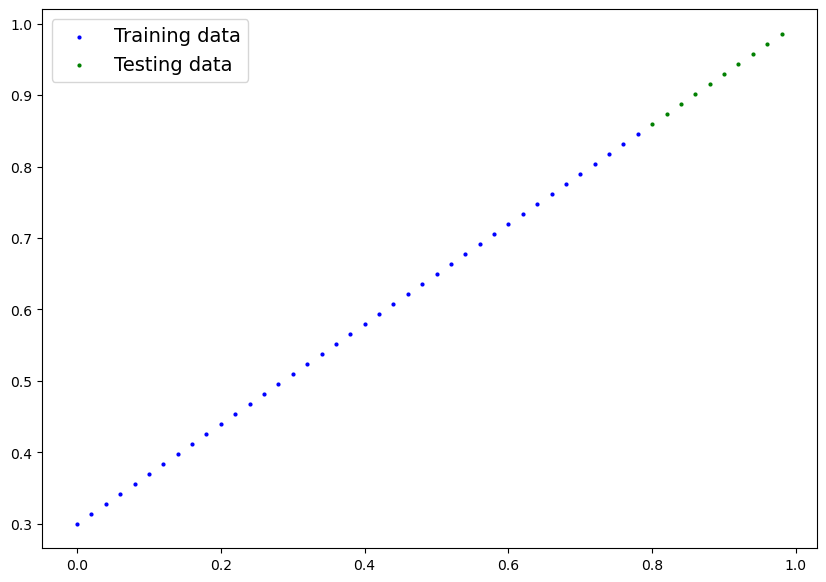

In [30]:
plot_predictions()

## 2. build model

Our first pytorch model

In [4]:
import torch
from torch import nn

In [5]:
# Create  Linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in pytorch inherits from nn.Module
    def __init__(self):
        super().__init__() #Run the __init__ method of my parent class
        #Initialize model parameters
        self.weights = nn.Parameter(torch.randn(1, # Start with the random weight and try to adjust it to the ideal weight
                                                requires_grad=True, # can this parameter be updated via gradient descent?
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, # Start with the random bias and try to adjust it to the ideal bias
                                             requires_grad=True, # can this parameter be updated via gradient descent?
                                             dtype=torch.float))
        
    # Forward method to define the computation in the model
    def forward(self,x: torch.Tensor) -> torch.Tensor: # x is the input data
        return self.weights * x + self.bias


### Checking the contents of out pytorch model

Now we have created a model lets see what's inside...

So we can check our model parameter or what's inside our model using `.parameters()`


In [9]:
import torch 
# Create the random seed 
torch.manual_seed(42)

#Create an instance of the model ( this is a subclass of nn.Module)

model_0 = LinearRegressionModel()

# check the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:
# List named paramters

model_0.state_dict()


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])